## Task 1

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
region_counts = df['region'].value_counts()
region_counts

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

## Task 2

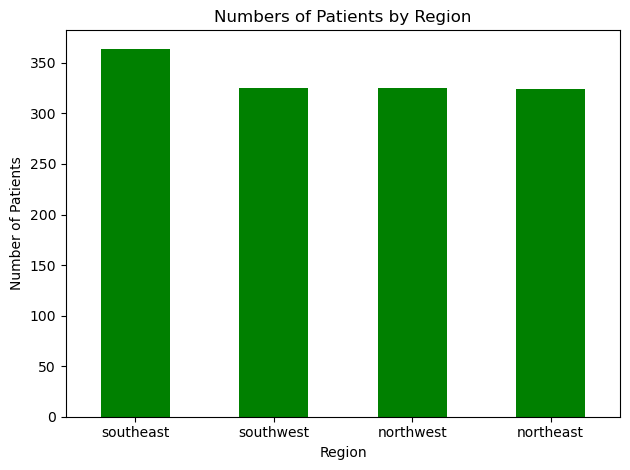

In [8]:
region_counts.plot(kind="bar",
                    title="Numbers of Patients by Region",
                    xlabel='Region',
                    ylabel='Number of Patients',
                    color='Green',
                    rot=0
                    
                    )

plt.tight_layout()
plt.show()



Yes title appears at top  
Yes they are labeled  
The axis labeel is flat


## Task 3

In [10]:
mean_charges_by_smoker = df.groupby('smoker')['charges'].mean()
mean_charges_by_smoker

smoker
no      8434.268298
yes    32050.231832
Name: charges, dtype: float64

<Axes: title={'center': 'Mean Insurance Charges: Smokers vs Non-Smokers'}, xlabel='Smoker', ylabel='Mean Charges (USD)'>

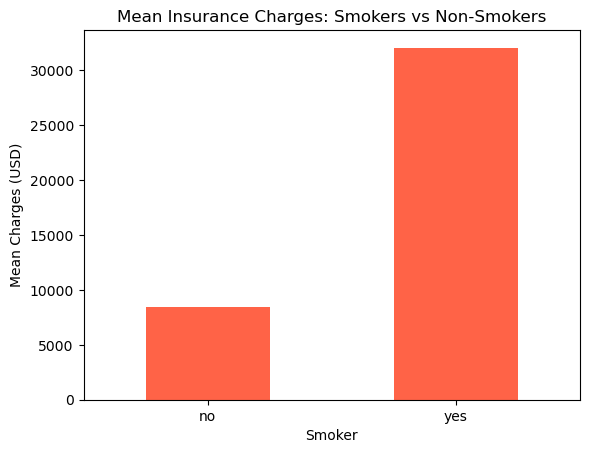

In [14]:
mean_charges_by_smoker.plot(kind="bar", 
                            title="Mean Insurance Charges: Smokers vs Non-Smokers",
                            xlabel='Smoker',
                            ylabel="Mean Charges (USD)",
                            color='tomato',
                            rot=0
                            )

#plt.tight_layout()
#plt.show()

On average, smoker charges are ~$20,000 higher than non-smoker charges. This is not surprising because it is a risk factor. 

## Task 4

In [17]:
median_charges_by_children =df.groupby('children')['charges'].median()
median_charges_by_children

children
0     9856.95190
1     8483.87015
2     9264.97915
3    10600.54830
4    11033.66170
5     8589.56505
Name: charges, dtype: float64

<Axes: title={'center': 'Median Charges by Number of Children'}, xlabel='Median Charges (USD)', ylabel='Number of Children'>

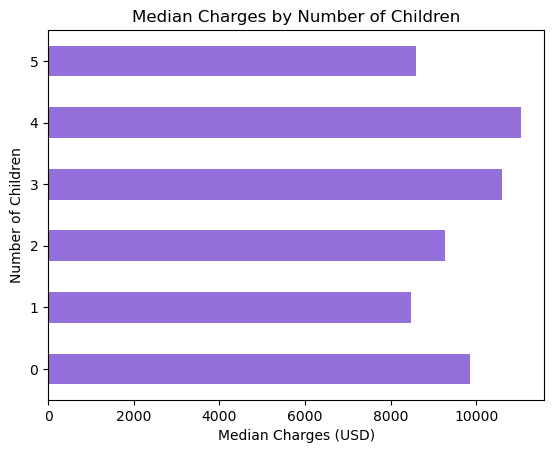

In [ ]:
median_charges_by_children.plot(kind="barh",
                                title="Median Charges by Number of Children",
                                xlabel="Median Charges (USD)",
                                ylabel="Number of Children",
                                color="mediumpurple"
)


No, having more children does not immediately appear to raise the charges
Something else could explain the lack of pattern

## Task 5

In [18]:
numeric_cols = df[["age", "bmi", "children", "charges"]]
numeric_cols.head()

,age,bmi,children,charges
0,19,27.900,0,16884.92400
1,18,33.770,1,1725.55230
2,28,33.000,3,4449.46200
3,33,22.705,0,21984.47061
4,32,28.880,0,3866.85520


In [19]:
corr = numeric_cols.corr()
print(corr)

               age       bmi  children   charges
age       1.000000  0.109272  0.042469  0.299008
bmi       0.109272  1.000000  0.012759  0.198341
children  0.042469  0.012759  1.000000  0.067998
charges   0.299008  0.198341  0.067998  1.000000


The strongest positive relationship exists between charges and age at .299  
There is no negative relationship to examine  
BMI has a weak relationship with charges

## Task 6

<Axes: title={'center': 'Age vs. Insurance Charges'}, xlabel='Age (years)', ylabel='Charges (USD)'>

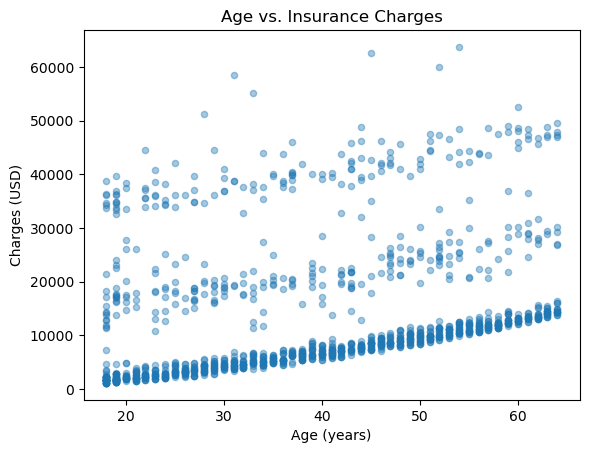

In [21]:
df.plot(kind="scatter",
        x='age',
        y='charges',
        title="Age vs. Insurance Charges",
        xlabel='Age (years)',
        ylabel="Charges (USD)",
        alpha=0.4
        )

The pattern looks like three lines  
There are cluster bands  
Yes because everything on the corr matrix had a positive correlation as shown in the scatter plot

## Task 7

In [22]:
df["smoker_num"] = (df["smoker"] == "yes").astype(int)

<Axes: title={'center': 'BMI vs. Charges (colored by Smoker Status)'}, xlabel='BMI', ylabel='Charges (USD)'>

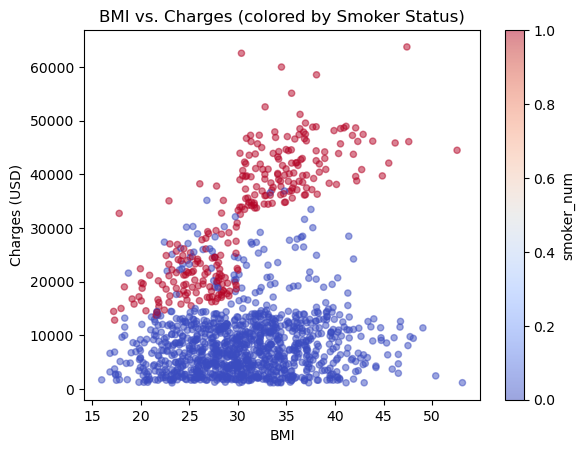

In [25]:
df.plot(kind="scatter",
        x='bmi',
        y='charges',
        c='smoker_num',
        colormap='coolwarm',
        title="BMI vs. Charges (colored by Smoker Status)",
        xlabel='BMI',
        ylabel="Charges (USD)",
        alpha=0.5
        )

Yes, they form separate clusters  
Smokers with a high BMI tend to have higher charges. Non-smokers, even those with a higher BMI tend to pay less. 

## Task 8

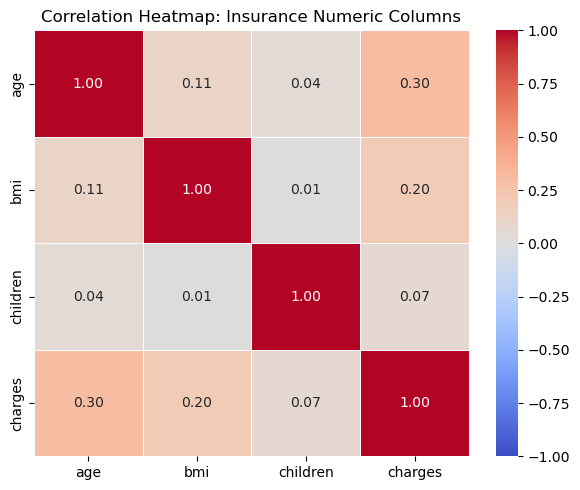

In [35]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr.round(2),
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            vmin=-1,
            vmax=1,
            linewidths=0.5,
            ax=ax

)
ax.set_title("Correlation Heatmap: Insurance Numeric Columns")
plt.tight_layout()
plt.show()

The 1.00 cells are the darkest red is the strongest positive correlation  
Darkest blue is the strongest negative correlation  
Near 0 : Children & BMI, children & charges, Children & age  
Yes the numbers agree



## Task 9

In [41]:
mean_region_charges= df.groupby('region')['charges'].mean().sort_values(ascending=False)
mean_region_charges

region
southeast    14735.411438
northeast    13406.384516
northwest    12417.575374
southwest    12346.937377
Name: charges, dtype: float64

<Axes: title={'center': 'Mean Charges by Region'}, xlabel='charges', ylabel='region'>

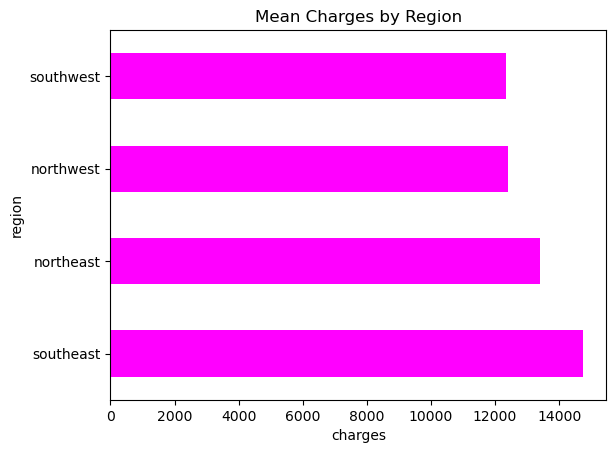

In [42]:
mean_region_charges.plot(kind="barh",
                        title="Mean Charges by Region",
                        xlabel="charges",
                        ylabel="region",
                        color="Magenta"
                         )

The difference in region is much smaller than in the smoker example from task 3

## Task 10

<Axes: title={'center': 'Age vs Charges'}, xlabel='Age', ylabel='Charges'>

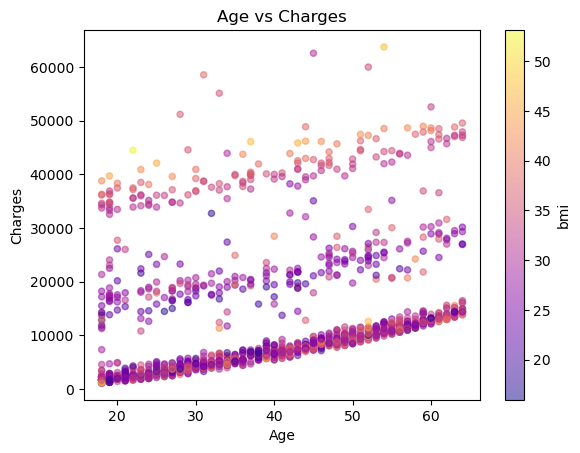

In [47]:
df.plot(kind="scatter",
        x="age",
        y="charges",
        c="bmi",
        colormap='plasma',
        alpha=0.5,
        title="Age vs Charges",
        xlabel="Age",
        ylabel="Charges"

        )

It is a mixed pattern of high-charge and low-charge patients. BMI does not separate them. 

## Task 11

In [52]:
smoker_by_sex = df.groupby(["sex", "smoker"]).size().unstack()
smoker_by_sex

smoker,no,yes
sex,,
female,547,115
male,517,159


<Axes: title={'center': 'Smoker Status by Sex'}, xlabel='Sex', ylabel='Frequency'>

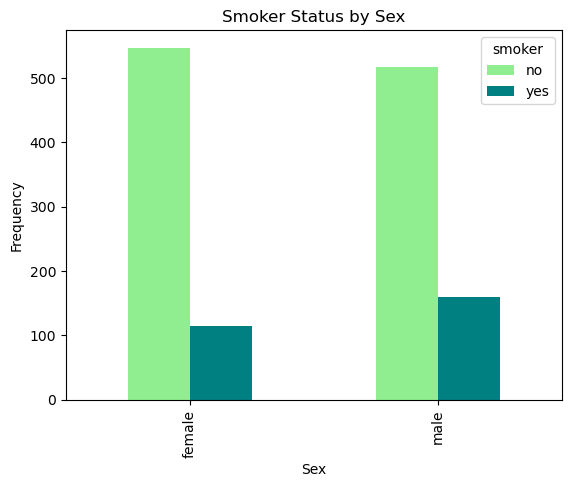

In [57]:
smoker_by_sex.plot(kind="bar",
                   title="Smoker Status by Sex",
                   xlabel="Sex",
                   ylabel="Frequency",
                   color=["LightGreen","Teal"]

)

Yes the smoker status is split roughly equal between males and females

## Task 12

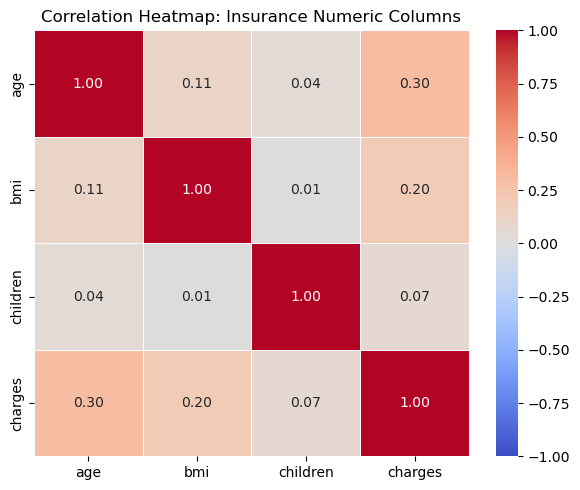

In [58]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr.round(2),
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            vmin=-1,
            vmax=1,
            linewidths=0.5,
            ax=ax

)
ax.set_title("Correlation Heatmap: Insurance Numeric Columns")
plt.tight_layout()
plt.show()

In [60]:
numeric_cols_next = df[["age", "bmi", "smoker_num", "charges"]]
corr_next = numeric_cols_next.corr()

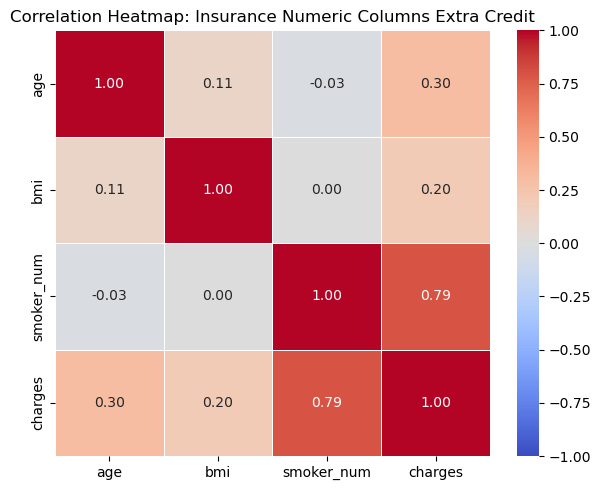

In [61]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_next.round(2),
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            vmin=-1,
            vmax=1,
            linewidths=0.5,
            ax=ax

)
ax.set_title("Correlation Heatmap: Insurance Numeric Columns Extra Credit")
plt.tight_layout()
plt.show()

Smokers correlates strongly with charges and slightly negative with age

## Task 13

1.When you want to compare numeric values, scatter plots are the better option.  When you are comparing the number of values in each category, bar charts show the picture well!  If something causes higher insurance costs is the question we were answering.  No Smoking!  
2. The amount of children and the cost of insurance. The correlation is .07, which is a weak positive correlation. There is likely another factor impacting this as the expectation is for more children to = higher charges.  
3. Smoking (and age) is the single factor most strongly linked to high insurance charges